# Train GNN Model
Notebook huấn luyện mô hình Graph Neural Network (GNN) cho bài toán phân loại tích phân.

In [93]:
import os
import sys
import pandas as pd
import numpy as np  
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import SAGEConv, global_mean_pool
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score

_NOTEBOOK_DIR = os.path.abspath(os.getcwd())
if os.path.basename(_NOTEBOOK_DIR) == 'model':
    _ROOT = os.path.abspath(os.path.join(_NOTEBOOK_DIR, '..', '..'))
elif os.path.basename(_NOTEBOOK_DIR) == 'ai':
    _ROOT = os.path.abspath(os.path.join(_NOTEBOOK_DIR, '..'))
else:
    _ROOT = _NOTEBOOK_DIR
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

from ai.utils.integral import Integral


Định nghĩa NODE

In [94]:
NODE_TYPE_MAP = {
    'VarExprNode': 0,
    'ConstExprNode': 1,
    'AddExprNode': 2,
    'SubExprNode': 3,
    'MulExprNode': 4,
    'FracExprNode': 5,
    'PowerExprNode': 6,
    'MonoExprNode': 7,
    'SqrtExprNode': 8,
    'SinExprNode': 9,
    'CosExprNode': 10,
    'TanExprNode': 11,
    'ExpExprNode': 12,
    'LogExprNode': 13,
}
NUM_NODE_FEATURES = len(NODE_TYPE_MAP)
print(f"Số loại node: {NUM_NODE_FEATURES}")

Số loại node: 14


In [95]:
def expr_to_graph(latex_str, label):
    try:
        parsed = Integral(latex_str)
        body = parsed.integrand
        if body is None:
            return None
    except Exception:
        return None

    node_features = []
    edges = []

    def traverse(curr_node, current_id):
        node_type = type(curr_node).__name__
        feature = [0.0] * NUM_NODE_FEATURES
        if node_type in NODE_TYPE_MAP:
            feature[NODE_TYPE_MAP[node_type]] = 1.0
        node_features.append(feature)

        if hasattr(curr_node, 'left') and curr_node.left is not None:
            left_id = len(node_features)
            edges.append([current_id, left_id])
            edges.append([left_id, current_id])
            traverse(curr_node.left, left_id)

        if hasattr(curr_node, 'right') and curr_node.right is not None:
            right_id = len(node_features)
            edges.append([current_id, right_id])
            edges.append([right_id, current_id])
            traverse(curr_node.right, right_id)

    traverse(body, 0)

    x = torch.tensor(node_features, dtype=torch.float)
    
    if len(edges) > 0:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    else:
        edge_index = torch.empty((2, 0), dtype=torch.long)
    y = torch.tensor(label, dtype=torch.long)
    return Data(x=x, edge_index=edge_index, y=y)

ĐỊNH NGHĨA MÔ HÌNH 

In [96]:
class IntegralGNN(torch.nn.Module):
    def __init__(self, num_features, hidden_channels, num_classes):
        super(IntegralGNN, self).__init__()
        self.conv1 = SAGEConv(num_features, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, hidden_channels)
        self.conv3 = SAGEConv(hidden_channels, hidden_channels)
        self.fc = Linear(hidden_channels, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        # Message Passing
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        x = F.relu(x)
        x = self.conv3(x, edge_index)
        x = F.relu(x)
        x = global_mean_pool(x, batch)

        x = F.dropout(x, p=0.5, training=self.training)
        x = self.fc(x)
        return x

In [97]:
def expr_to_graph_with_labels(latex_str):
    from ai.utils.integral import Integral
    import networkx as nx

    try:
        parsed = Integral(latex_str)
        body = parsed.integrand
        if body is None:
            return None
    except Exception:
        return None

    G = nx.DiGraph()
    nodes_info = []
    edges = []
    node_features = []

    def traverse(curr_node, current_id):
        node_type = type(curr_node).__name__
        feature = [0.0] * NUM_NODE_FEATURES
        if node_type in NODE_TYPE_MAP:
            feature[NODE_TYPE_MAP[node_type]] = 1.0
        
        label = node_type.replace("ExprNode", "")
        if node_type == 'VarExprNode':
            label = str(curr_node.left) if curr_node.left is not None else "x"
        elif node_type == 'ConstExprNode':
            label = str(curr_node.left) if curr_node.left is not None else "c"
        elif node_type == 'AddExprNode':
            label = "+"
        elif node_type == 'SubExprNode':
            label = "-"
        elif node_type == 'MulExprNode':
            label = "*"
        elif node_type == 'FracExprNode':
            label = "/"
        elif node_type == 'PowerExprNode':
            label = "^"
        elif node_type == 'SqrtExprNode':
            label = "√"
        elif node_type == 'SinExprNode':
            label = "sin"
        elif node_type == 'CosExprNode':
            label = "cos"
        elif node_type == 'TanExprNode':
            label = "tan"
        elif node_type == 'ExpExprNode':
            label = "exp"
        elif node_type == 'LogExprNode':
            label = "ln"

        nodes_info.append({
            "id": current_id,
            "type": node_type,
            "label": label,
            "feature": feature
        })
        node_features.append(feature)
        G.add_node(current_id, label=label, type=node_type)

        if hasattr(curr_node, 'left') and curr_node.left is not None:
            left_id = len(nodes_info)
            edges.append([current_id, left_id])
            G.add_edge(current_id, left_id)
            traverse(curr_node.left, left_id)

        if hasattr(curr_node, 'right') and curr_node.right is not None:
            right_id = len(nodes_info)
            edges.append([current_id, right_id])
            G.add_edge(current_id, right_id)
            traverse(curr_node.right, right_id)

    traverse(body, 0)

    pos = {}
    x_coords = {}
    inorder_nodes = []
    
    def get_inorder(u):
        neighbors = list(G.successors(u))
        if len(neighbors) > 0:
            get_inorder(neighbors[0])
        inorder_nodes.append(u)
        if len(neighbors) > 1:
            get_inorder(neighbors[1])
            
    if G.number_of_nodes() > 0:
        get_inorder(0)
        
    for i, u in enumerate(inorder_nodes):
        x_coords[u] = i
        
    depths = {0: 0}
    def find_depths(u, d):
        for v in G.successors(u):
            depths[v] = d + 1
            find_depths(v, d + 1)
            
    if G.number_of_nodes() > 0:
        find_depths(0, 0)
        
    for u in G.nodes():
        pos[u] = (x_coords[u], -depths[u])

    pyg_edges = []
    for edge in edges:
        pyg_edges.append([edge[0], edge[1]])
        pyg_edges.append([edge[1], edge[0]])
        
    x = torch.tensor(node_features, dtype=torch.float)
    edge_index = (
        torch.tensor(pyg_edges, dtype=torch.long).t().contiguous()
        if pyg_edges
        else torch.empty((2, 0), dtype=torch.long)
    )
    
    data = Data(x=x, edge_index=edge_index)
    data.batch = torch.zeros(data.num_nodes, dtype=torch.long)

    return data, G, pos, nodes_info

def get_model_predictions_and_embeddings(model, data):
    model.eval()
    with torch.no_grad():
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x1 = F.relu(model.conv1(x, edge_index))
        x2 = F.relu(model.conv2(x1, edge_index))
        x3 = F.relu(model.conv3(x2, edge_index))
        pooled = global_mean_pool(x3, batch)
        logits = model.fc(pooled)
        probs = F.softmax(logits, dim=-1).squeeze(0)
    return x3.cpu().numpy(), probs.cpu().numpy()

def evaluate_embedding_separability(model, loader, title_suffix="Before Training"):
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    from sklearn.metrics import silhouette_score
    import numpy as np

    model.eval()
    all_embeddings = []
    all_labels = []
    device = next(model.parameters()).device

    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            x, edge_index, batch = data.x, data.edge_index, data.batch
            x1 = F.relu(model.conv1(x, edge_index))
            x2 = F.relu(model.conv2(x1, edge_index))
            x3 = F.relu(model.conv3(x2, edge_index))
            pooled = global_mean_pool(x3, batch)
            
            all_embeddings.append(pooled.cpu().numpy())
            all_labels.append(data.y.cpu().numpy())

    embeddings = np.concatenate(all_embeddings, axis=0)
    labels = np.concatenate(all_labels, axis=0)

    score = silhouette_score(embeddings, labels)
    print(f"[{title_suffix}] Silhouette Score of Graph Embeddings: {score:.4f}")

    pca = PCA(n_components=2)
    coords = pca.fit_transform(embeddings)

    ACTION_NAMES = [
        "Rut hang so",
        "Tach tong/hieu",
        "Cong thuc dac trung",
        "Doi bien u=ax+b",
        "Tich phan tung phan"
    ]
    
    plt.figure(figsize=(10, 8))
    colors = ['#ef4444', '#3b82f6', '#10b981', '#f59e0b', '#8b5cf6']
    for class_idx in range(len(ACTION_NAMES)):
        mask = (labels == class_idx)
        plt.scatter(
            coords[mask, 0], coords[mask, 1],
            label=f"{class_idx}: {ACTION_NAMES[class_idx]}",
            alpha=0.7, edgecolors='black', linewidth=0.5, s=60, color=colors[class_idx]
        )

    plt.title(f"GNN Graph Embeddings Separability ({title_suffix})\nSilhouette Score: {score:.4f}", fontsize=13, fontweight='bold')
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(frameon=True, facecolor='white', edgecolor='gray')
    plt.tight_layout()
    plt.show()


In [98]:
print("Đang đọc dữ liệu từ dataset...")
df = pd.read_csv(os.path.join(_ROOT, "ai", "data", "processed", "dataset.csv"))
df['action'] = pd.to_numeric(df['action'], errors='coerce')
df = df.dropna(subset=['action'])
df['action'] = df['action'].astype(int)

unique_actions = sorted(df['action'].unique())
label_to_index = {action: idx for idx, action in enumerate(unique_actions)}
num_classes = len(label_to_index)
print(f"Số lớp (actions): {num_classes}")
print(f"Tổng số mẫu: {len(df)}")

if num_classes == 0:
    raise ValueError("Không tìm thấy nhãn hợp lệ trong dataset.")

Đang đọc dữ liệu từ dataset...
Số lớp (actions): 5
Tổng số mẫu: 3528


In [99]:
graph_dataset = []
invalid_count = 0
for _, row in df.iterrows():
    latex = row['integrand']
    raw_label = int(row['action'])
    label = label_to_index[raw_label]
    data = expr_to_graph(latex, label)
    if data is not None:
        graph_dataset.append(data)
    else:
        invalid_count += 1

print(f"Tổng số mẫu đồ thị hợp lệ: {len(graph_dataset)}, không hợp lệ: {invalid_count}")

if len(graph_dataset) == 0:
    raise ValueError("Không có dữ liệu đồ thị hợp lệ để huấn luyện.")

Tổng số mẫu đồ thị hợp lệ: 3468, không hợp lệ: 60


In [100]:
train_data, test_data = train_test_split(graph_dataset, test_size=0.2, random_state=42)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

print(f"Train: {len(train_data)} mẫu, Test: {len(test_data)} mẫu")

Train: 2774 mẫu, Test: 694 mẫu


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Sử dụng thiết bị huấn luyện: {device}")

model = IntegralGNN(num_features=NUM_NODE_FEATURES, hidden_channels=64, num_classes=num_classes).to(device)


labels = [data.y.item() for data in train_data]
unique_train_labels = np.unique(labels)
if len(unique_train_labels) == num_classes and num_classes > 1:
    class_weights = compute_class_weight('balanced', classes=np.arange(num_classes), y=labels)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
    criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)
    print("Dùng class weights để cân bằng dữ liệu.")
else:
    criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.005)

Sử dụng thiết bị huấn luyện: cpu


Dùng class weights để cân bằng dữ liệu.
Khởi tạo mô hình thành công!


Dang kiem tra do phan tach du lieu (Silhouette Score) truoc khi train...


[Before Training - Test Set] Silhouette Score of Graph Embeddings: 0.0102


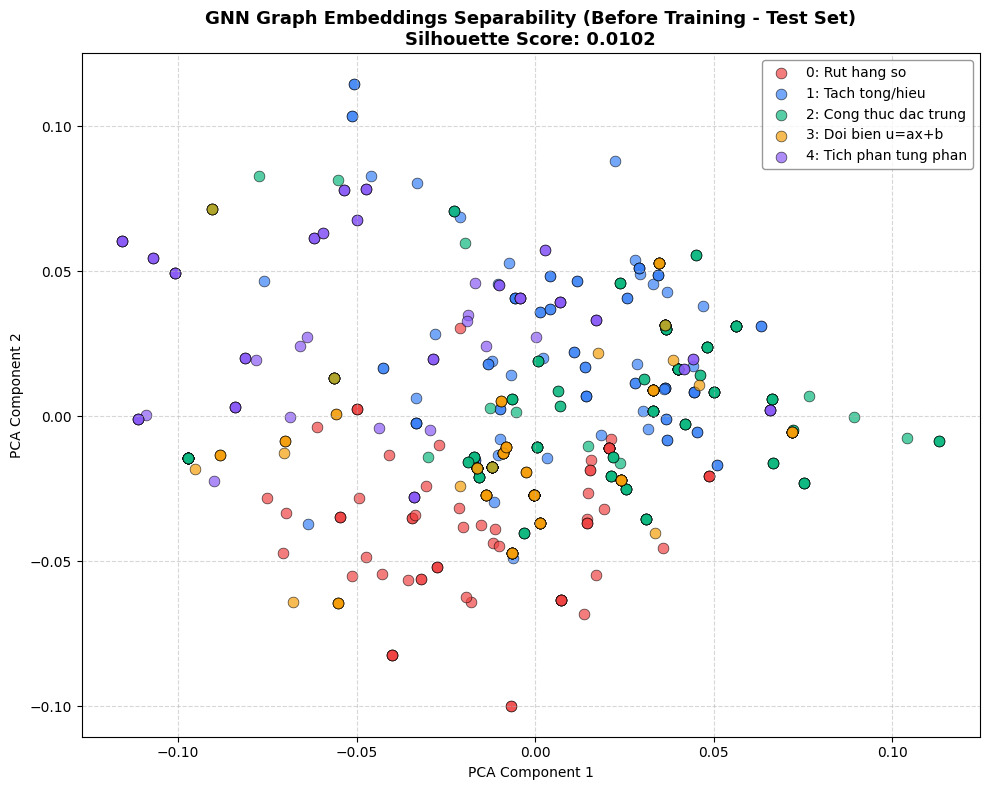

In [102]:
print("Dang kiem tra do phan tach du lieu (Silhouette Score) truoc khi train...")
evaluate_embedding_separability(model, test_loader, "Before Training - Test Set")

In [ ]:
for epoch in range(1, 201):
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    
    train_loss = total_loss / len(train_loader.dataset)
    model.eval()
    correct = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            out = model(data)
            pred = out.argmax(dim=1)
            
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(data.y.cpu().numpy())
            
            correct += int((pred == data.y).sum())
    
    test_acc = correct / len(test_loader.dataset)
    test_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    if epoch % 10 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {train_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1-Macro: {test_f1:.4f}')



Epoch: 010, Loss: 0.3427, Test Acc: 0.8977, Test F1-Macro: 0.8990
Epoch: 020, Loss: 0.1834, Test Acc: 0.9424, Test F1-Macro: 0.9517
Epoch: 030, Loss: 0.1335, Test Acc: 0.9654, Test F1-Macro: 0.9679
Epoch: 040, Loss: 0.1120, Test Acc: 0.9553, Test F1-Macro: 0.9622
Epoch: 050, Loss: 0.1049, Test Acc: 0.9568, Test F1-Macro: 0.9629
Epoch: 060, Loss: 0.0857, Test Acc: 0.9654, Test F1-Macro: 0.9679
Epoch: 070, Loss: 0.0796, Test Acc: 0.9467, Test F1-Macro: 0.9579
Epoch: 080, Loss: 0.0818, Test Acc: 0.9568, Test F1-Macro: 0.9636
Epoch: 090, Loss: 0.0869, Test Acc: 0.9510, Test F1-Macro: 0.9589
Epoch: 100, Loss: 0.0806, Test Acc: 0.9640, Test F1-Macro: 0.9670
Epoch: 110, Loss: 0.0720, Test Acc: 0.9697, Test F1-Macro: 0.9735
Epoch: 120, Loss: 0.0733, Test Acc: 0.9582, Test F1-Macro: 0.9653
Epoch: 130, Loss: 0.0666, Test Acc: 0.9654, Test F1-Macro: 0.9685
Epoch: 140, Loss: 0.0663, Test Acc: 0.9438, Test F1-Macro: 0.9546
Epoch: 150, Loss: 0.0659, Test Acc: 0.9669, Test F1-Macro: 0.9707
Epoch: 160

In [ ]:
_SAVED = os.path.join(_ROOT, "ai", "saved_models")
os.makedirs(_SAVED, exist_ok=True)
model_path = os.path.join(_SAVED, "best_gnn_model.pth")
torch.save(model.state_dict(), model_path)

In [ ]:
import random
from collections import Counter
from torch_geometric.loader import DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report

print("--- Huấn luyện GNN với Random Over-Sampling (ROS) ---")

labels_before = [data.y.item() for data in train_data]
print("Phân phối nhãn trước khi cân bằng (Train set):", Counter(labels_before))
counts = Counter(labels_before)
max_count = max(counts.values())
train_data_oversampled = []
grouped_data = {label: [] for label in counts.keys()}
for data in train_data:
    grouped_data[data.y.item()].append(data)
for label, items in grouped_data.items():
    train_data_oversampled.extend(items)
    num_to_add = max_count - len(items)
    if num_to_add > 0:
        train_data_oversampled.extend(random.choices(items, k=num_to_add))

labels_after = [data.y.item() for data in train_data_oversampled]
print("Phân phối nhãn sau khi cân bằng (Train set):", Counter(labels_after))
train_loader_ros = DataLoader(train_data_oversampled, batch_size=64, shuffle=True)
model_ros = IntegralGNN(num_features=NUM_NODE_FEATURES, hidden_channels=64, num_classes=num_classes).to(device)
optimizer_ros = torch.optim.Adam(model_ros.parameters(), lr=0.005)
criterion_ros = torch.nn.CrossEntropyLoss() # Không cần class weights vì dữ liệu đã cân bằng
best_f1_ros = 0.0
for epoch in range(1, 201):
    model_ros.train()
    total_loss = 0
    for data in train_loader_ros:
        data = data.to(device)
        optimizer_ros.zero_grad()
        out = model_ros(data)
        loss = criterion_ros(out, data.y)
        loss.backward()
        optimizer_ros.step()
        total_loss += loss.item() * data.num_graphs
    
    train_loss = total_loss / len(train_loader_ros.dataset)

    # Đánh giá trên tập test
    model_ros.eval()
    correct = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for data in test_loader:
            data = data.to(device)
            out = model_ros(data)
            pred = out.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(data.y.cpu().numpy())
            correct += int((pred == data.y).sum())
    
    test_acc = correct / len(test_loader.dataset)
    test_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    
    if test_f1 > best_f1_ros:
        best_f1_ros = test_f1
        torch.save(model_ros.state_dict(), os.path.join(_SAVED, "best_gnn_model_ros.pth"))
        
    if epoch % 20 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {train_loss:.4f}, Test Acc: {test_acc:.4f}, Test F1-Macro: {test_f1:.4f}')
print(f"\nHuấn luyện ROS hoàn thành! F1-Macro tốt nhất: {best_f1_ros:.4f}")
model_ros.load_state_dict(torch.load(os.path.join(_SAVED, "best_gnn_model_ros.pth")))
model_ros.eval()
y_true_ros = []
y_pred_ros = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model_ros(data)
        pred = out.argmax(dim=1)
        y_true_ros.extend(data.y.cpu().numpy())
        y_pred_ros.extend(pred.cpu().numpy())

ACTION_NAMES = [
    "Rut hang so",
    "Tach tong/hieu",
    "Cong thuc dac trung",
    "Doi bien u=ax+b",
    "Tich phan tung phan"
]

print("\nBÁO CÁO CHI TIẾT HIỆU NĂNG PHÂN LOẠI (ROS GNN):")
print(classification_report(y_true_ros, y_pred_ros, target_names=ACTION_NAMES, zero_division=0))

evaluate_embedding_separability(model_ros, test_loader, "ROS GNN - Test Set")


In [ ]:
from imblearn.over_sampling import SMOTE
import numpy as np
from torch.utils.data import TensorDataset, DataLoader as PyTorchDataLoader
from sklearn.metrics import classification_report
model.load_state_dict(torch.load(os.path.join(_SAVED, "best_gnn_model.pth")))

model.eval()
train_embeddings = []
train_labels = []
with torch.no_grad():
    for data in train_loader:
        data = data.to(device)
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x1 = F.relu(model.conv1(x, edge_index))
        x2 = F.relu(model.conv2(x1, edge_index))
        x3 = F.relu(model.conv3(x2, edge_index))
        pooled = global_mean_pool(x3, batch)
        train_embeddings.append(pooled.cpu().numpy())
        train_labels.append(data.y.cpu().numpy())

X_tr_emb = np.concatenate(train_embeddings, axis=0)
y_tr_emb = np.concatenate(train_labels, axis=0)
test_embeddings = []
test_labels = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x1 = F.relu(model.conv1(x, edge_index))
        x2 = F.relu(model.conv2(x1, edge_index))
        x3 = F.relu(model.conv3(x2, edge_index))
        pooled = global_mean_pool(x3, batch)
        test_embeddings.append(pooled.cpu().numpy())
        test_labels.append(data.y.cpu().numpy())
X_te_emb = np.concatenate(test_embeddings, axis=0)
y_te_emb = np.concatenate(test_labels, axis=0)
smote = SMOTE(random_state=42)
X_tr_res, y_tr_res = smote.fit_resample(X_tr_emb, y_tr_emb)
tr_dataset = TensorDataset(torch.tensor(X_tr_res, dtype=torch.float32), torch.tensor(y_tr_res, dtype=torch.long))
tr_loader_emb = PyTorchDataLoader(tr_dataset, batch_size=64, shuffle=True)

classifier = torch.nn.Linear(64, num_classes).to(device)
optimizer_clf = torch.optim.Adam(classifier.parameters(), lr=0.01)
criterion_clf = torch.nn.CrossEntropyLoss()

for epoch in range(1, 101):
    classifier.train()
    for emb_batch, labels_batch in tr_loader_emb:
        emb_batch = emb_batch.to(device)
        labels_batch = labels_batch.to(device)
        optimizer_clf.zero_grad()
        preds = classifier(emb_batch)
        loss = criterion_clf(preds, labels_batch)
        loss.backward()
        optimizer_clf.step()

model.fc.weight.data.copy_(classifier.weight.data)
model.fc.bias.data.copy_(classifier.bias.data)
torch.save(model.state_dict(), os.path.join(_SAVED, "best_gnn_model_smote.pth"))
model.eval()
y_true_smote = []
y_pred_smote = []
with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data)
        pred = out.argmax(dim=1)
        y_true_smote.extend(data.y.cpu().numpy())
        y_pred_smote.extend(pred.cpu().numpy())

ACTION_NAMES = [
    "Rut hang so",
    "Tach tong/hieu",
    "Cong thuc dac trung",
    "Doi bien u=ax+b",
    "Tich phan tung phan"
]

print("\nBÁO CÁO CHI TIẾT HIỆU NĂNG PHÂN LOẠI (GNN + SMOTE):")
print(classification_report(y_true_smote, y_pred_smote, target_names=ACTION_NAMES, zero_division=0))

print("Dang kiem tra do phan tach du lieu (Silhouette Score) cua GNN + SMOTE...")
evaluate_embedding_separability(model, test_loader, "GNN + SMOTE - Test Set")


In [ ]:
print("Dang kiem tra do phan tach du lieu (Silhouette Score) sau khi train...")
evaluate_embedding_separability(model, test_loader, "After Training - Test Set")

In [ ]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 50)
print("          THÔNG SỐ MÔ HÌNH INTEGRALGNN")
print("=" * 50)
print(f"Tổng số tham số (Total parameters):      {total_params:,}")
print(f"Tham số huấn luyện (Trainable params):    {trainable_params:,}")
print("-" * 50)
print("Chi tiết các lớp mạng (Layer Details):")
for name, param in model.named_parameters():
    print(f"  - {name:<12}: shape={str(list(param.shape)):<18} | numel={param.numel():,}")
print("=" * 50)

          THÔNG SỐ MÔ HÌNH INTEGRALGNN
Tổng số tham số (Total parameters):      18,693
Tham số huấn luyện (Trainable params):    18,693
--------------------------------------------------
Chi tiết các lớp mạng (Layer Details):


TypeError: unsupported format string passed to list.__format__

BÁO CÁO CHI TIẾT HIỆU NĂNG PHÂN LOẠI (Classification Report):
                        precision    recall  f1-score   support

        0: Rút hằng số       1.00      0.96      0.98        90
     1: Tách tổng/hiệu       0.94      1.00      0.97        87
2: Công thức đặc trưng       0.93      0.99      0.96       138
    3: Đổi biến u=ax+b       1.00      0.92      0.96       145
4: Tích phân từng phần       0.99      1.00      0.99        78

              accuracy                           0.97       538
             macro avg       0.97      0.97      0.97       538
          weighted avg       0.97      0.97      0.97       538



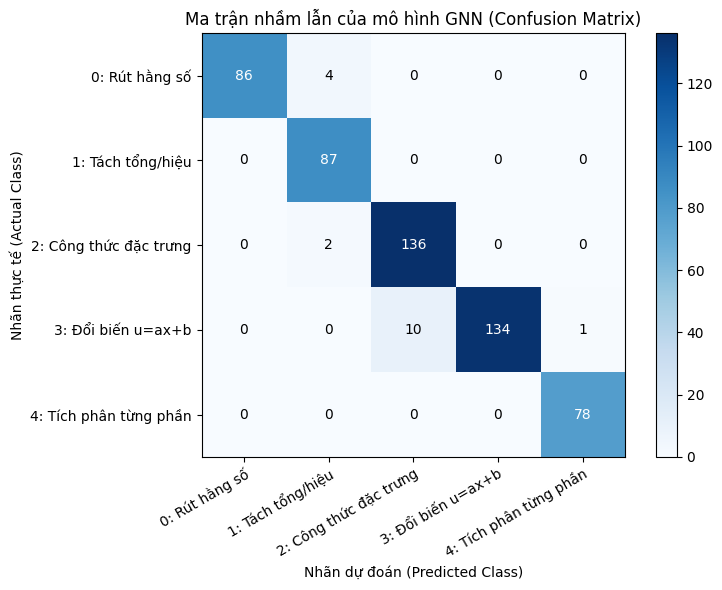

In [ ]:
# 12. Đánh giá mô hình GNN - Ma trận nhầm lẫn (Confusion Matrix)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data)
        pred = out.argmax(dim=1)
        y_true.extend(data.y.cpu().numpy())
        y_pred.extend(pred.cpu().numpy())

action_names = [
    "0: Rút hằng số",
    "1: Tách tổng/hiệu",
    "2: Công thức đặc trưng",
    "3: Đổi biến u=ax+b",
    "4: Tích phân từng phần"
]

print("BÁO CÁO CHI TIẾT HIỆU NĂNG PHÂN LOẠI (Classification Report):")
print(classification_report(y_true, y_pred, target_names=action_names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)

try:
    import seaborn as sns
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        cm, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        xticklabels=action_names, 
        yticklabels=action_names
    )
    plt.title("Ma trận nhầm lẫn của mô hình GNN (Confusion Matrix)", fontsize=14, pad=15)
    plt.xlabel("Nhãn dự đoán (Predicted Class)", fontsize=12, labelpad=10)
    plt.ylabel("Nhãn thực tế (Actual Class)", fontsize=12, labelpad=10)
    plt.xticks(rotation=30, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()
except ImportError:
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=action_names, yticklabels=action_names,
           title="Ma trận nhầm lẫn của mô hình GNN (Confusion Matrix)",
           ylabel="Nhãn thực tế (Actual Class)",
           xlabel="Nhãn dự đoán (Predicted Class)")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right", rotation_mode="anchor")
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    plt.show()